# My final Project
By Timmy Koheler

In [1]:
import numpy as np
import sep
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Ellipse

In [2]:
rcParams['figure.figsize'] = [10., 8.] #Set standard figure parameters 

In [3]:
fname = 'hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits' #pull data from home directory 
dat = fits.getdata("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

In [4]:
m, s = np.mean(dat), np.std(dat) #define mean and standard deviation on the data

## Origional Image Plot

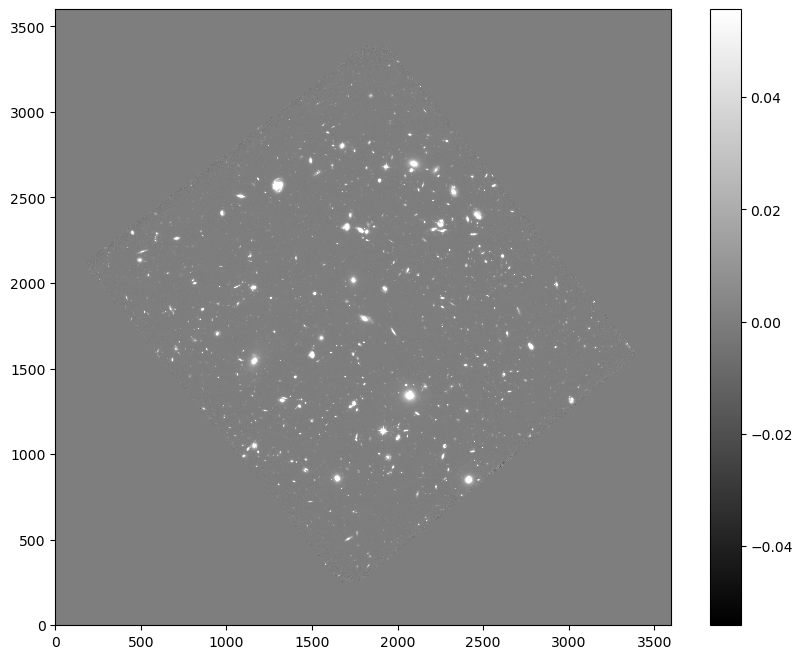

In [5]:
plt.imshow(dat, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower') #plot origional data
plt.colorbar();

## Background Plot

In [6]:
dat = dat.astype(dat.dtype.newbyteorder('=')) #reorder aray 
bkg = sep.Background(dat) #separate background 
bkg = sep.Background(dat, bw=200, bh=200, fw=10, fh=10) 

In [7]:
bkg_image = bkg.back()

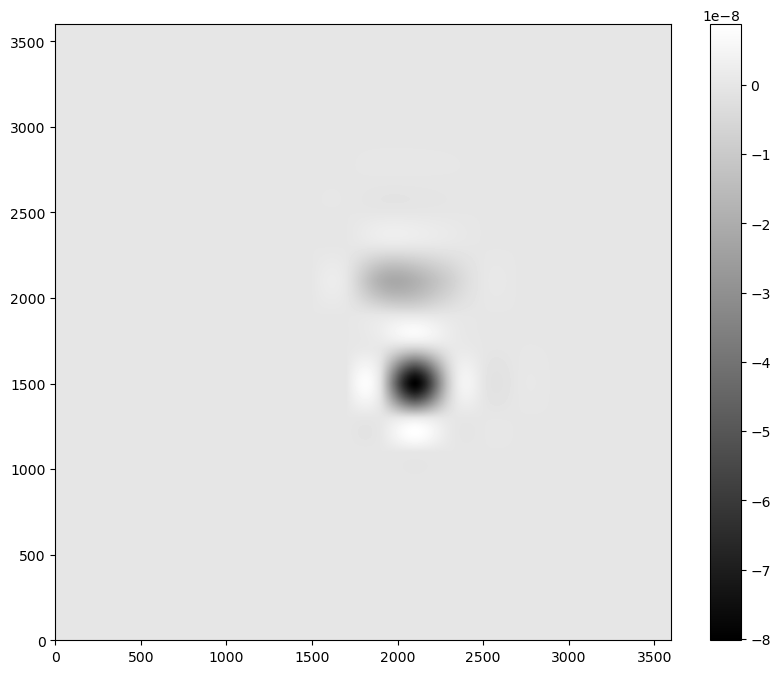

In [8]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower') #plot just the background 
plt.colorbar(); 

## Background Noise Plot

In [9]:
bkg_rms = bkg.rms()

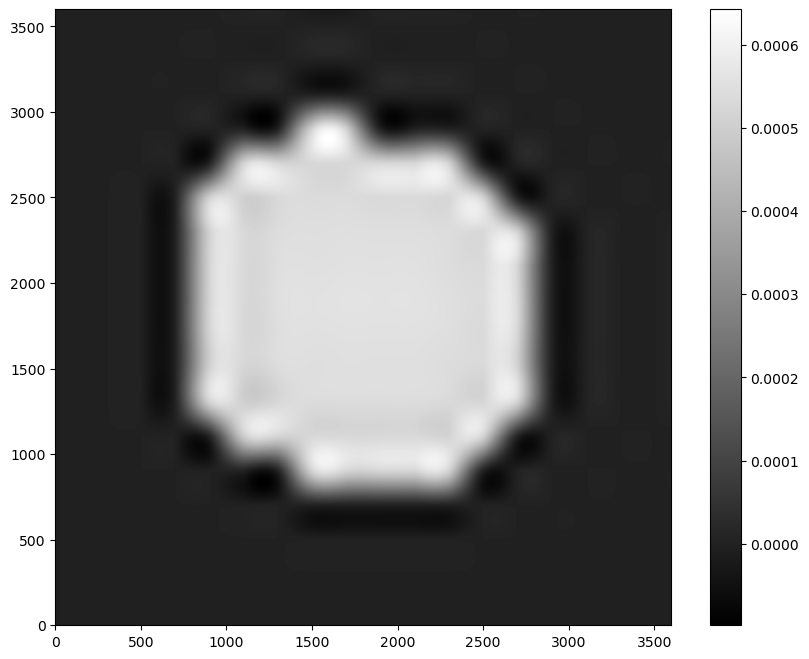

In [10]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower') #show backgrond noise as an aray
plt.colorbar();

## Plot of The Sources

In [11]:
data_sub = dat - bkg #get just the sources by subtracting the background from the origional figure 

In [12]:
objects = sep.extract(data_sub, 50, err=bkg.globalrms) #identify how many sources 

In [13]:
print(f"there are {len(objects)} sources in this model") 

there are 483 sources in this model


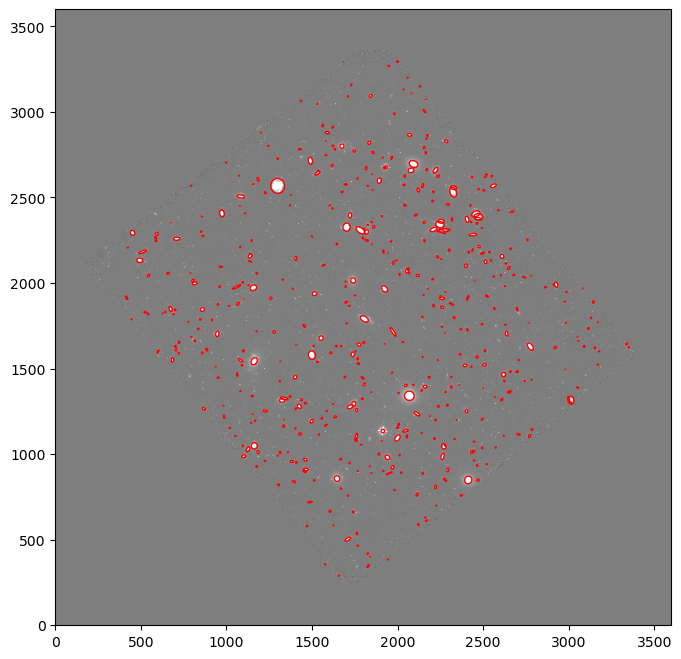

In [14]:
fig, ax = plt.subplots() #plot just the sources 
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [20]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0) #Pull flux data 

In [21]:
for i in range(483):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 1.150759 +/- 1.072738
object 1: flux = 1.122997 +/- 1.059719
object 2: flux = 0.853392 +/- 0.923797
object 3: flux = 0.679008 +/- 0.824024
object 4: flux = 0.761177 +/- 0.872459
object 5: flux = 1.249486 +/- 1.117808
object 6: flux = 0.970262 +/- 0.985023
object 7: flux = 3.219485 +/- 1.794294
object 8: flux = 1.057755 +/- 1.028476
object 9: flux = 1.422169 +/- 1.192551
object 10: flux = 0.673763 +/- 0.820835
object 11: flux = 2.250540 +/- 1.500182
object 12: flux = 1.215164 +/- 1.102348
object 13: flux = 0.797581 +/- 0.893078
object 14: flux = 8.210452 +/- 2.865390
object 15: flux = 1.307329 +/- 1.143388
object 16: flux = 0.770891 +/- 0.878009
object 17: flux = 1.411896 +/- 1.188236
object 18: flux = 1.026230 +/- 1.013034
object 19: flux = 1.929734 +/- 1.389151
object 20: flux = 1.480409 +/- 1.216724
object 21: flux = 1.046327 +/- 1.022905
object 22: flux = 1.419558 +/- 1.191456
object 23: flux = 2.021342 +/- 1.421742
object 24: flux = 2.309017 +/- 1.519548
object 25:

## Flux Data Histogram 

Text(0.5, 1.0, 'Histogram of fluxes from different sources in the top figure')

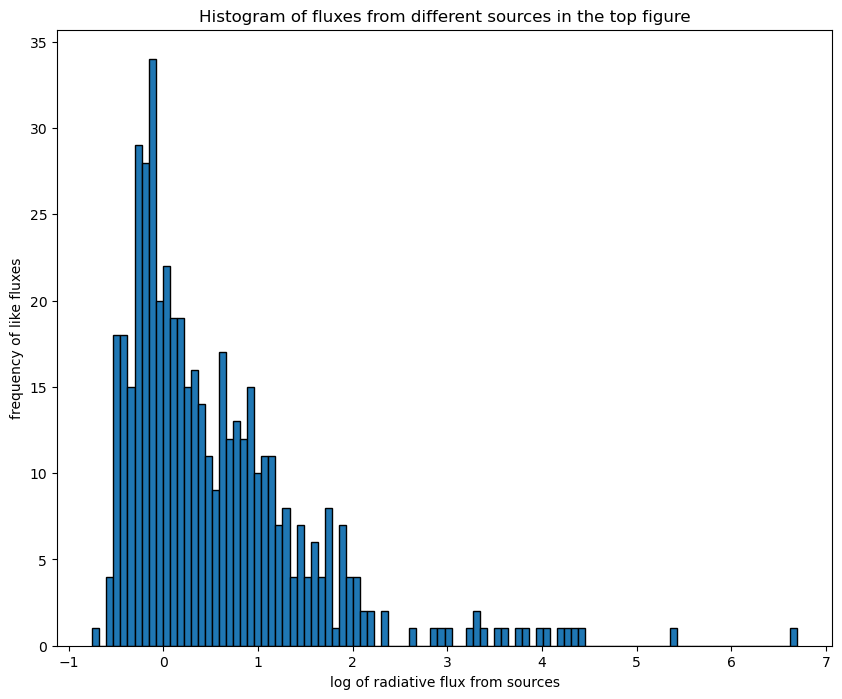

In [22]:
plt.hist(np.log(flux), bins = 100, edgecolor="black") #plot flux data into a histogram
plt.xlabel("log of radiative flux from sources")
plt.ylabel("frequency of like fluxes")
plt.title("Histogram of fluxes from different sources in the top figure")

In [23]:
print(f"The mean of all of the fluxes is {np.mean(flux):5f}\nThe median of the all of the fluxes is {np.median(flux):5f}\nThe standard deviation of all the fluxes is {np.std(flux):5f}")

The mean of all of the fluxes is 5.552128
The median of the all of the fluxes is 1.322696
The standard deviation of all the fluxes is 38.703142


In [24]:
print(f"the largest outlier in the distribution of fluxes is around {max(flux)} which is about {max(flux)/np.std(flux)} standard deviations away from the mean.")

the largest outlier in the distribution of fluxes is around 806.5230277442932 which is about 20.83869668470081 standard deviations away from the mean.
